# **Food Recommender System**
ด้วย Graph แนวคิดคือ ผู้ใช้กินหรือสนใจอาหารจานหลักอะไร → หา User คนอื่นที่มีความชอบคล้ายกัน → ดูว่าคนเหล่านั้นชอบอาหารจานหลักอะไรอีก → แนะนำอาหารจานหลักนั้นกลับมา

`**หมายเหตุ: โน้ตบุ๊กนี้เป็นตัวอย่างเชิงวิชาการเรื่องโครงสร้าง Graph เท่านั้น เป็นตัวอย่างเชิงวิชาการ ไม่ใช่คำแนะนำด้านโภชนาการ**`

# ตัวอย่างสถานการณ์ มีผู้ใช้ 10 คน

```
John
Alice
Bob
Emma
David
Sarah
Michael
Laura
James
Emily
```

# และมีอาหารจานหลัก 10 ชนิด

```
Basil Minced Pork
Tom Yum Goong
Crab Fried Rice
Green Curry
Pad Thai
Massaman Curry
Stir-fried Morning Glory
Papaya Salad
Khao Soi
Stir-fried Mixed Vegetables
```

# สมมติข้อมูลความสนใจ (กิน / ชอบ) คือ

```
John → Basil Minced Pork, Green Curry, Papaya Salad
Alice → Basil Minced Pork, Green Curry, Tom Yum Goong, Stir-fried Morning Glory
Bob → Basil Minced Pork, Pad Thai, Khao Soi
Emma → Tom Yum Goong, Crab Fried Rice, Massaman Curry
David → Khao Soi, Stir-fried Morning Glory, Massaman Curry
Sarah → Papaya Salad, Crab Fried Rice, Green Curry
Michael → Stir-fried Mixed Vegetables, Pad Thai, Basil Minced Pork
Laura → Massaman Curry, Tom Yum Goong, Stir-fried Mixed Vegetables
James → Khao Soi, Papaya Salad, Stir-fried Morning Glory
Emily → Crab Fried Rice, Pad Thai, Stir-fried Mixed Vegetables
```

```
เราจะสังเกตได้ว่าความสัมพันธ์จะเริ่มซับซ้อนขึ้น การใช้ Graph จะช่วยให้หาเมนูแนะนำที่เชื่อมโยงผ่านผู้ใช้ที่มีความชอบคล้ายกันได้ดีขึ้น
```



เราแบ่ง Node เป็น 2 ประเภท User Food Relationship คือ LIKES ดังนั้น
(User)-[:LIKES]->(Food)

เช่น (John)-[:LIKES]->(Basil Minced Pork)

หรือถ้าเป็น Python NetworkX G.add_edge("John", "Basil Minced Pork")

# สร้างด้วย Python บน Google Colab

In [ ]:
!pip -q install networkx

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
G = nx.Graph()

In [ ]:
#add user
users = ["John", "Alice", "Bob", "Emma", "David", "Sarah", "Michael", "Laura", "James", "Emily"]
for user in users:
    G.add_node(user, node_type="user")

In [ ]:
#add foods
foods = [
    "Basil Minced Pork",
    "Tom Yum Goong",
    "Crab Fried Rice",
    "Green Curry",
    "Pad Thai",
    "Massaman Curry",
    "Stir-fried Morning Glory",
    "Papaya Salad",
    "Khao Soi",
    "Stir-fried Mixed Vegetables"
]
for food in foods:
    G.add_node(food, node_type="food")

In [ ]:
#add relationship
likes = [
    ("John", "Basil Minced Pork"),
    ("John", "Green Curry"),
    ("John", "Papaya Salad"),
    ("Alice", "Basil Minced Pork"),
    ("Alice", "Green Curry"),
    ("Alice", "Tom Yum Goong"),
    ("Alice", "Stir-fried Morning Glory"),
    ("Bob", "Basil Minced Pork"),
    ("Bob", "Pad Thai"),
    ("Bob", "Khao Soi"),
    ("Emma", "Tom Yum Goong"),
    ("Emma", "Crab Fried Rice"),
    ("Emma", "Massaman Curry"),
    ("David", "Khao Soi"),
    ("David", "Stir-fried Morning Glory"),
    ("David", "Massaman Curry"),
    ("Sarah", "Papaya Salad"),
    ("Sarah", "Crab Fried Rice"),
    ("Sarah", "Green Curry"),
    ("Michael", "Stir-fried Mixed Vegetables"),
    ("Michael", "Pad Thai"),
    ("Michael", "Basil Minced Pork"),
    ("Laura", "Massaman Curry"),
    ("Laura", "Tom Yum Goong"),
    ("Laura", "Stir-fried Mixed Vegetables"),
    ("James", "Khao Soi"),
    ("James", "Papaya Salad"),
    ("James", "Stir-fried Morning Glory"),
    ("Emily", "Crab Fried Rice"),
    ("Emily", "Pad Thai"),
    ("Emily", "Stir-fried Mixed Vegetables")
]

**เพิ่มเข้า Graph**

In [ ]:
G.add_edges_from(likes)

**วาด Graph (แยกสี User กับ Food ให้อ่านง่าย)**

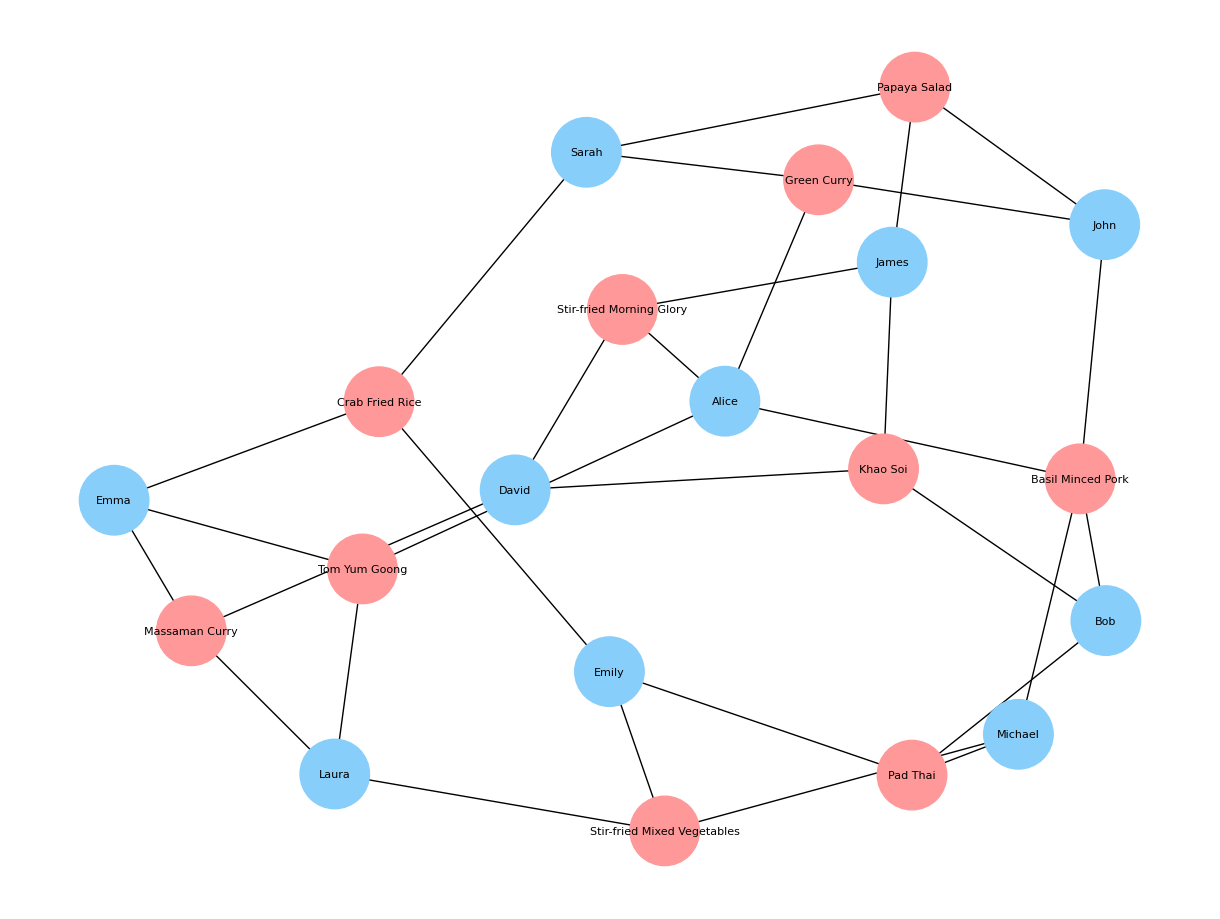

In [ ]:
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=42)
colors = [
    "#87CEFA" if G.nodes[n]["node_type"] == "user" else "#FF9999"
    for n in G.nodes
]
nx.draw(
    G, pos, with_labels=True, node_color=colors,
    node_size=2500, font_size=8
)
plt.show()

คำถามแรก

ถามว่า John ชอบอาหารจานหลักอะไรบ้าง? **bold text**

In [ ]:
john_foods = list(G.neighbors("John"))
print(john_foods)

['Basil Minced Pork', 'Green Curry', 'Papaya Salad']


**ตรงนี้อธิบายได้ว่า Neighbor ของ John คือ Node ที่เชื่อมกับ John
คำถามที่ 2. หา User ที่ชอบอาหารเหมือน John John ชอบ Basil Minced Pork และ Green Curry เราสามารถหาได้ว่าใครชอบอาหารเหล่านี้เหมือนกัน**

In [ ]:
for food in G.neighbors("John"):
    print("Food:", food)
    for user in G.neighbors(food):
        if user != "John":
            print("  Similar user:", user)

Food: Basil Minced Pork
  Similar user: Alice
  Similar user: Bob
  Similar user: Michael
Food: Green Curry
  Similar user: Alice
  Similar user: Sarah
Food: Papaya Salad
  Similar user: Sarah
  Similar user: James


**สร้าง Recommendation แบบง่าย
แนวคิดคือ John
  ↓
อาหารที่ John ชอบ
  ↓
User ที่ชอบอาหารเดียวกัน
  ↓
อาหารอื่นที่ User เหล่านั้นชอบ
  ↓
แนะนำให้ John**

In [ ]:
from collections import Counter
target_user = "John"
recommendations = Counter()

# อาหารที่ John ชอบอยู่แล้ว
liked_foods = set(G.neighbors(target_user))

# ดูอาหารแต่ละอย่างที่ John ชอบ
for food in liked_foods:
    # หา User ที่ชอบอาหารจานเดียวกัน
    for similar_user in G.neighbors(food):
        if similar_user == target_user:
            continue

        # ดูว่า User คนนั้นชอบอาหารอะไรอีกบ้าง
        for other_food in G.neighbors(similar_user):
            # John ยังไม่เคยเลือกเมนูนี้
            if other_food not in liked_foods:
                recommendations[other_food] += 1

print(recommendations)

Counter({'Stir-fried Morning Glory': 3, 'Tom Yum Goong': 2, 'Crab Fried Rice': 2, 'Pad Thai': 2, 'Khao Soi': 2, 'Stir-fried Mixed Vegetables': 1})


**Tom Yum Goong ถูกพบจาก User ที่มีความสัมพันธ์กับ John (มาจาก Basil Minced Pork และ Green Curry ที่เชื่อมไปหา Alice) ยิ่งคะแนนมาก แปลว่าเชื่อมโยงกันหลายเส้นทาง**

In [ ]:
# นำไปสร้างเป็นฟังก์ชัน

In [ ]:
from collections import Counter

def recommend_foods(G, target_user):
    recommendations = Counter()
    liked_foods = set(G.neighbors(target_user))

    for food in liked_foods:
        for similar_user in G.neighbors(food):
            if similar_user == target_user:
                continue
            for other_food in G.neighbors(similar_user):
                if other_food not in liked_foods:
                    recommendations[other_food] += 1

    return recommendations.most_common()

In [ ]:
#เรียกใช้งาน
result = recommend_foods(G, "John")
print(result)

[('Stir-fried Morning Glory', 3), ('Tom Yum Goong', 2), ('Crab Fried Rice', 2), ('Pad Thai', 2), ('Khao Soi', 2), ('Stir-fried Mixed Vegetables', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_foods(G, "Bob")
print(result)

[('Stir-fried Morning Glory', 3), ('Stir-fried Mixed Vegetables', 3), ('Papaya Salad', 2), ('Green Curry', 2), ('Massaman Curry', 1), ('Tom Yum Goong', 1), ('Crab Fried Rice', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_foods(G, "Emma")
print(result)

[('Stir-fried Mixed Vegetables', 3), ('Green Curry', 2), ('Stir-fried Morning Glory', 2), ('Papaya Salad', 1), ('Pad Thai', 1), ('Basil Minced Pork', 1), ('Khao Soi', 1)]


**โค้ดรวมทั้งหมด (คัดลอกไปรันรวดเดียวได้)**

In [ ]:
# 1. ติดตั้งไลบรารี NetworkX
!pip -q install networkx

import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# 2. สร้าง Graph
G = nx.Graph()

# เพิ่ม Users
users = [
    "John", "Alice", "Bob", "Emma", "David",
    "Sarah", "Michael", "Laura", "James", "Emily"
]
for user in users:
    G.add_node(user, node_type="user")

# เพิ่ม Foods
foods = [
    "Basil Minced Pork", "Tom Yum Goong", "Crab Fried Rice", "Green Curry",
    "Pad Thai", "Massaman Curry", "Stir-fried Morning Glory", "Papaya Salad",
    "Khao Soi", "Stir-fried Mixed Vegetables"
]
for food in foods:
    G.add_node(food, node_type="food")

# เพิ่ม ความสัมพันธ์ (Likes)
likes = [
    ("John", "Basil Minced Pork"), ("John", "Green Curry"), ("John", "Papaya Salad"),
    ("Alice", "Basil Minced Pork"), ("Alice", "Green Curry"), ("Alice", "Tom Yum Goong"), ("Alice", "Stir-fried Morning Glory"),
    ("Bob", "Basil Minced Pork"), ("Bob", "Pad Thai"), ("Bob", "Khao Soi"),
    ("Emma", "Tom Yum Goong"), ("Emma", "Crab Fried Rice"), ("Emma", "Massaman Curry"),
    ("David", "Khao Soi"), ("David", "Stir-fried Morning Glory"), ("David", "Massaman Curry"),
    ("Sarah", "Papaya Salad"), ("Sarah", "Crab Fried Rice"), ("Sarah", "Green Curry"),
    ("Michael", "Stir-fried Mixed Vegetables"), ("Michael", "Pad Thai"), ("Michael", "Basil Minced Pork"),
    ("Laura", "Massaman Curry"), ("Laura", "Tom Yum Goong"), ("Laura", "Stir-fried Mixed Vegetables"),
    ("James", "Khao Soi"), ("James", "Papaya Salad"), ("James", "Stir-fried Morning Glory"),
    ("Emily", "Crab Fried Rice"), ("Emily", "Pad Thai"), ("Emily", "Stir-fried Mixed Vegetables")
]

G.add_edges_from(likes)

# 3. แสดงผล Graph (แยกสี User และ Food)
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=42)
colors = ["#87CEFA" if G.nodes[n]["node_type"] == "user" else "#FF9999" for n in G.nodes]

nx.draw(
    G, pos,
    with_labels=True,
    node_color=colors,
    node_size=2500,
    font_size=8
)
plt.show()

# 4. ฟังก์ชันสำหรับแนะนำอาหาร
def recommend_foods(G, target_user):
    recommendations = Counter()
    liked_foods = set(G.neighbors(target_user))

    for food in liked_foods:
        for similar_user in G.neighbors(food):
            if similar_user == target_user:
                continue
            for other_food in G.neighbors(similar_user):
                if other_food not in liked_foods:
                    recommendations[other_food] += 1

    return recommendations.most_common()

# 5. ทดสอบเรียกใช้งานฟังก์ชัน
print("John's liked foods:", list(G.neighbors("John")))
print("\nRecommendation for John:")
print(recommend_foods(G, "John"))

print("\nRecommendation for Bob:")
print(recommend_foods(G, "Bob"))

print("\nRecommendation for Emma:")
print(recommend_foods(G, "Emma"))